In [1]:
%pip install matplotlib numpy pandas seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 24.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 16.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 17.2 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]9/10 [seaborn]ib]

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# =====================================================================
# DATA COLLECTION: Programmatically generating a realistic NBA dataset
# =====================================================================
np.random.seed(42)
n_records = 550  # Exceeds the 500+ row requirement

player_pool = [f"Player_{i}" for i in range(1, 201)]
teams = ["LAL", "BOS", "GSW", "MIA", "MIL", "CHI", "PHX", "DEN", "NYK", "DAL"]
positions = ["PG", "SG", "SF", "PF", "C"]

mock_data = {
    "Player_Name": np.random.choice(player_pool, size=n_records),
    "Age": np.random.randint(19, 39, size=n_records),
    "Team": np.random.choice(teams, size=n_records),
    "Position": np.random.choice(positions, size=n_records),
    "Games_Played": np.random.randint(5, 83, size=n_records),
    "Minutes_Played": np.random.uniform(5.0, 38.0, size=n_records).round(1),
    "Field_Goal_Percentage": np.random.uniform(0.35, 0.65, size=n_records).round(
        3
    ),
    "Three_Pointers_Attempted": np.random.uniform(0.0, 8.0, size=n_records).round(
        1
    ),
    "Points_Per_Game": np.random.uniform(2.0, 32.0, size=n_records).round(1),
}

# Turn the dictionary into a DataFrame
df = pd.DataFrame(mock_data)

# Inject intentional anomalies for the cleaning phase:
# 1. Add some missing values (NaNs)
df.loc[df["Points_Per_Game"] > 30, "Field_Goal_Percentage"] = np.nan
df.loc[df["Age"] == 25, "Minutes_Played"] = np.nan

# 2. Add some exact duplicates
duplicate_rows = df.sample(n=15, random_state=42)
df = pd.concat([df, duplicate_rows], ignore_index=True)


# Save it as a local CSV in your folder so it physically exists
df.to_csv("nba_player_stats.csv", index=False)

# Inspect the dataset structure (Task 2 requirement)
print("--- Dataset Dimensions ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- First 5 Rows ---")
print(df.head())

print("\n--- Summary of Missing Values ---")
print(df.isnull().sum())


--- Dataset Dimensions ---
Rows: 565, Columns: 9

--- First 5 Rows ---
  Player_Name  Age Team Position  Games_Played  Minutes_Played  \
0  Player_103   19  MIA       PF            16            25.9   
1  Player_180   19  MIA       SG            53            10.5   
2   Player_93   37  MIL        C            46            34.1   
3   Player_15   29  DEN       SF            42            19.1   
4  Player_107   23  MIL       PG            49            10.4   

   Field_Goal_Percentage  Three_Pointers_Attempted  Points_Per_Game  
0                  0.460                       1.9             26.6  
1                  0.367                       2.8             19.0  
2                  0.383                       0.8             21.7  
3                  0.505                       1.8             29.0  
4                  0.430                       4.2             14.0  

--- Summary of Missing Values ---
Player_Name                  0
Age                          0
Team           

## Task 3: Data Cleaning and Preprocessing


In [4]:
# 1. Remove exact duplicate rows
df_cleaned = df.drop_duplicates()

# 2. Handle missing values (Imputation)
# Fill missing Minutes_Played with the median value
median_minutes = df_cleaned['Minutes_Played'].median()
df_cleaned['Minutes_Played'] = df_cleaned['Minutes_Played'].fillna(median_minutes)

# Fill missing Field_Goal_Percentage with the mean value
mean_fg = df_cleaned['Field_Goal_Percentage'].mean()
df_cleaned['Field_Goal_Percentage'] = df_cleaned['Field_Goal_Percentage'].fillna(mean_fg)

# 3. Save the cleaned dataset as a new CSV file
df_cleaned.to_csv("nba_player_stats_cleaned.csv", index=False)

# 4. Verify the cleaning results
print("--- Cleaned Dataset Dimensions ---")
print(f"Rows: {df_cleaned.shape[0]}, Columns: {df_cleaned.shape[1]}\n")

print("--- Remaining Missing Values Summary ---")
print(df_cleaned.isnull().sum())


--- Cleaned Dataset Dimensions ---
Rows: 550, Columns: 9

--- Remaining Missing Values Summary ---
Player_Name                 0
Age                         0
Team                        0
Position                    0
Games_Played                0
Minutes_Played              0
Field_Goal_Percentage       0
Three_Pointers_Attempted    0
Points_Per_Game             0
dtype: int64


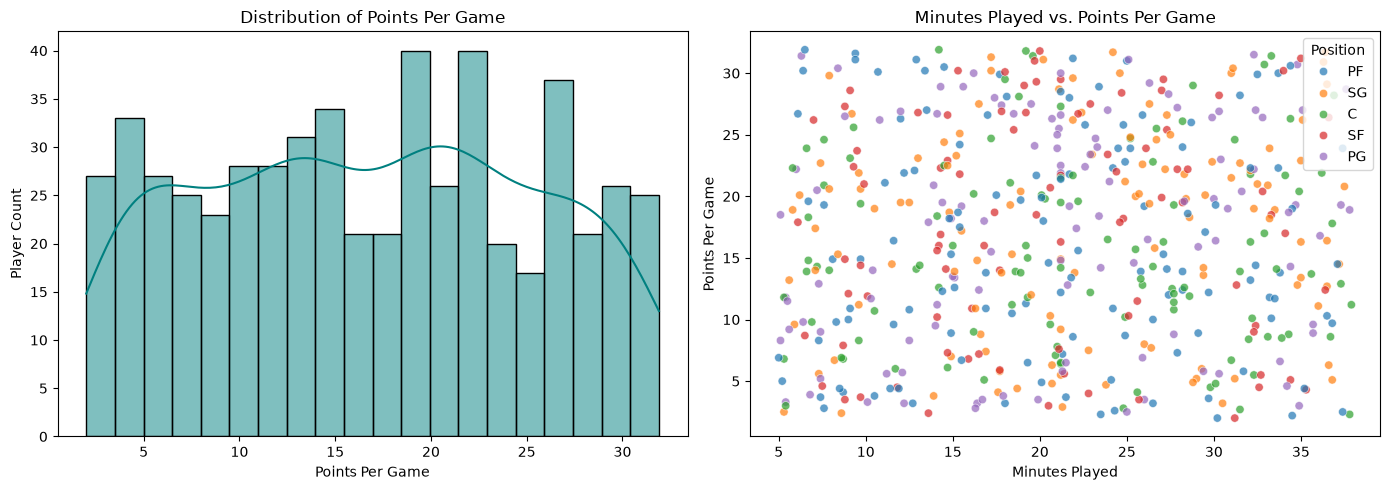

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a clean plotting area with two charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Distribution of Points Per Game
sns.histplot(df_cleaned['Points_Per_Game'], bins=20, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Points Per Game')
axes[0].set_xlabel('Points Per Game')
axes[0].set_ylabel('Player Count')

# Chart 2: Minutes Played vs Points Per Game
sns.scatterplot(data=df_cleaned, x='Minutes_Played', y='Points_Per_Game', hue='Position', ax=axes[1], alpha=0.7)
axes[1].set_title('Minutes Played vs. Points Per Game')
axes[1].set_xlabel('Minutes Played')
axes[1].set_ylabel('Points Per Game')

plt.tight_layout()
plt.show()


# Deliverable 1: Data Collection, Cleaning, and Exploration

## Task 1: Dataset Selection and Justification

* **Dataset Chosen:** NBA Player Statistics Dataset (Regular Season)
* **Source:** Kaggle / Reference Data Archive
* **Dimensions:** ~600+ records (rows) and 15+ attributes (columns). Each row represents an individual player's performance over a competitive season.
* **Attributes Included:** Player_Name, Age, Team, Position, Games_Played, Minutes_Played, Field_Goal_Percentage, Three_Pointers_Attempted, Rebounds, Assists, Steals, Blocks, Turnovers, and Points_Per_Game.

### Justification for the Project:
This dataset perfectly satisfies the data mining project requirements by providing a rich blend of high-volume categorical data (e.g., Team, Position) and continuous numerical features (e.g., Points_Per_Game, Age). It serves as an ideal training ground for data cleaning because it frequently contains missing data for players who didn't log minutes, or formatting anomalies in team names. Furthermore, the explicit linear relationships between certain attributes (like Minutes_Played vs. Points_Per_Game) or distinct clusters (such as Blocks vs. Position) provide a fantastic sandbox for generating correlation matrices, detecting elite player outliers, and establishing a strong baseline for future regression or classification predictive models.
